# Shape Measurements on Binary Masks

This notebook demonstrates common 2D shape measurements computed with `skimage.measure.regionprops`  
on **four canonical mask shapes**:

| Shape | Description |
|---|---|
| Circle | Perfectly circular object |
| Flower / Lobed | 5-petal flower (irregular boundary) |
| Rectangle | Elongated rectangular object |
| Cell | Irregular, blob-like cell shape |

All measurements are derived from binary masks (0 = background, 1 = object).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, FancyArrowPatch
import matplotlib.patheffects as pe
import pandas as pd
from skimage import draw, measure
from skimage.measure import regionprops, moments, moments_central, moments_normalized, moments_hu
from scipy.ndimage import binary_fill_holes, distance_transform_edt
from skimage.morphology import convex_hull_image

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.labelsize': 9})
COLORS = {'Circle': '#4C72B0', 'Flower': '#DD8452',
          'Rectangle': '#55A868', 'Cell': '#C44E52'}
print('Imports OK')

Imports OK


## 1 — Create the four binary masks

In [2]:
SIZE = 256
CX, CY = SIZE // 2, SIZE // 2

# ── Circle ────────────────────────────────────────────────────────────────
circle_mask = np.zeros((SIZE, SIZE), dtype=np.uint8)
rr, cc = draw.disk((CX, CY), radius=90, shape=circle_mask.shape)
circle_mask[rr, cc] = 1

# ── Flower (5 petals) ─────────────────────────────────────────────────────
flower_mask = np.zeros((SIZE, SIZE), dtype=np.uint8)
theta = np.linspace(0, 2 * np.pi, 3000)
r = 40 + 60 * np.abs(np.cos(5 / 2 * theta))
rows = (CX + r * np.sin(theta)).astype(int)
cols = (CY + r * np.cos(theta)).astype(int)
valid = (rows >= 0) & (rows < SIZE) & (cols >= 0) & (cols < SIZE)
flower_mask[rows[valid], cols[valid]] = 1
flower_mask = binary_fill_holes(flower_mask).astype(np.uint8)

# ── Rectangle ─────────────────────────────────────────────────────────────
rect_mask = np.zeros((SIZE, SIZE), dtype=np.uint8)
rect_mask[CX-40:CX+40, CY-100:CY+100] = 1

# ── Irregular cell ────────────────────────────────────────────────────────
from scipy.interpolate import interp1d
rng = np.random.default_rng(42)
n_bumps = 14
bump_angles = np.linspace(0, 2 * np.pi, n_bumps, endpoint=False)
bump_r = 70 + rng.integers(-28, 30, size=n_bumps)
angles_ext = np.concatenate([bump_angles - 2*np.pi, bump_angles, bump_angles + 2*np.pi])
radii_ext  = np.concatenate([bump_r, bump_r, bump_r])
interp = interp1d(angles_ext, radii_ext, kind='cubic')
theta2 = np.linspace(0, 2 * np.pi, 4000)
r2 = interp(theta2)
cell_mask = np.zeros((SIZE, SIZE), dtype=np.uint8)
rows2 = (CX + r2 * np.sin(theta2)).astype(int)
cols2 = (CY + r2 * np.cos(theta2)).astype(int)
valid2 = (rows2 >= 0) & (rows2 < SIZE) & (cols2 >= 0) & (cols2 < SIZE)
cell_mask[rows2[valid2], cols2[valid2]] = 1
cell_mask = binary_fill_holes(cell_mask).astype(np.uint8)

masks = {'Circle': circle_mask, 'Flower': flower_mask,
         'Rectangle': rect_mask, 'Cell': cell_mask}
print('Masks created:', {k: v.sum() for k, v in masks.items()})

Masks created: {'Circle': 25433, 'Flower': 20772, 'Rectangle': 16000, 'Cell': 17319}


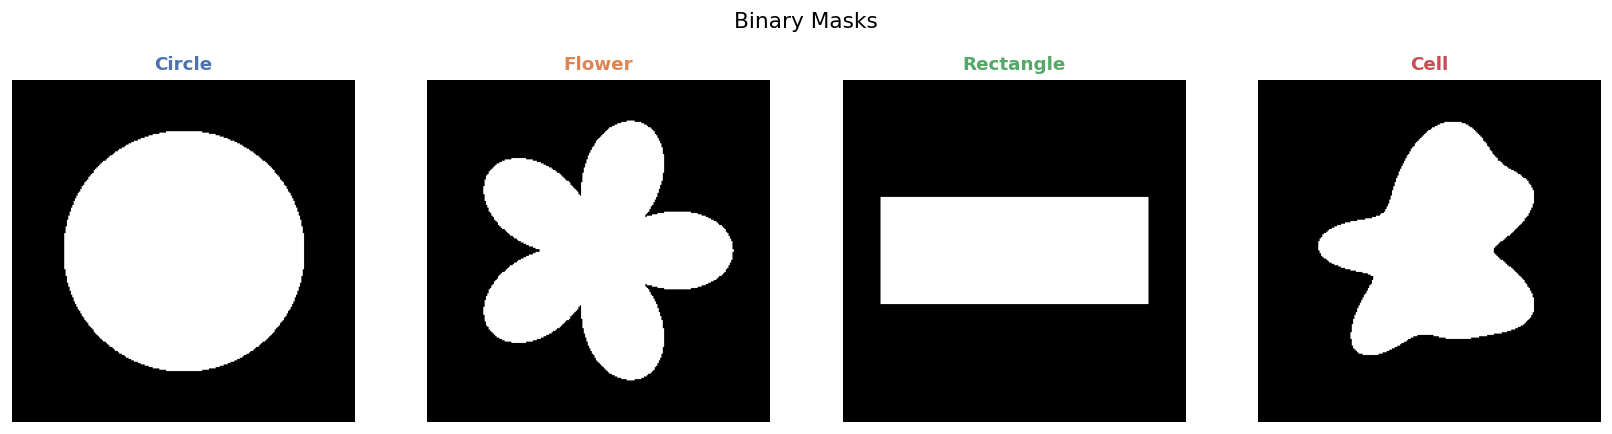

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (name, mask) in zip(axes, masks.items()):
    ax.imshow(mask, cmap='gray', vmin=0, vmax=1)
    ax.set_title(name, color=COLORS[name], fontweight='bold')
    ax.axis('off')
plt.suptitle('Binary Masks', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2 — Compute all measurements

In [5]:
def compute_props(mask):
    """Return a dict of shape properties for a single-object mask."""
    labeled = measure.label(mask)
    props = regionprops(labeled)[0]

    area  = props.area
    perim = props.perimeter if props.perimeter > 0 else np.nan
    convex_area = props.convex_area
    bbox  = props.bbox
    bbox_area = (bbox[2] - bbox[0]) * (bbox[3] - bbox[1])

    dist = distance_transform_edt(mask)
    obj_dist = dist[mask.astype(bool)]
    max_radius    = obj_dist.max()
    mean_radius   = obj_dist.mean()
    median_radius = np.median(obj_dist)

    max_idx = np.argmax(dist)
    center_y, center_x = np.unravel_index(max_idx, dist.shape)

    hu             = props.moments_hu
    inertia_tensor = props.inertia_tensor
    inertia_eigs   = props.inertia_tensor_eigvals

    d = {
        'Area': area, 'Perimeter': perim,
        'FormFactor':  (4 * np.pi * area / perim**2) if perim > 0 else np.nan,
        'Compactness': (perim**2 / (4 * np.pi * area)) if area > 0 else np.nan,
        'Solidity': props.solidity, 'Extent': props.extent,
        'Eccentricity': props.eccentricity, 'EulerNumber': props.euler_number,
        'ConvexArea': convex_area, 'BoundingBoxArea': bbox_area,
        'BBox_MinRow': bbox[0], 'BBox_MinCol': bbox[1],
        'BBox_MaxRow': bbox[2], 'BBox_MaxCol': bbox[3],
        'Center_Y': center_y, 'Center_X': center_x,
        'Centroid_Y': props.centroid[0], 'Centroid_X': props.centroid[1],
        'MajorAxisLength': props.major_axis_length,
        'MinorAxisLength': props.minor_axis_length,
        'EquivalentDiameter': props.equivalent_diameter_area,
        'Orientation_deg': np.degrees(props.orientation),
        'MaximumRadius': max_radius, 'MedianRadius': median_radius,
        'MeanRadius': mean_radius,
        'MaxFeretDiameter': props.feret_diameter_max,
        'MinFeretDiameter': np.nan,
    }
    for i in range(props.moments.shape[0]):
        for j in range(props.moments.shape[1]):
            d[f'Moment_{i}{j}'] = props.moments[i, j]
    for i in range(props.moments_central.shape[0]):
        for j in range(props.moments_central.shape[1]):
            d[f'CentralMoment_{i}{j}'] = props.moments_central[i, j]
    for i in range(props.moments_normalized.shape[0]):
        for j in range(props.moments_normalized.shape[1]):
            d[f'NormalizedMoment_{i}{j}'] = props.moments_normalized[i, j]
    for i, val in enumerate(hu):
        d[f'HuMoment_{i+1}'] = val
    for i in range(inertia_tensor.shape[0]):
        for j in range(inertia_tensor.shape[1]):
            d[f'InertiaTensor_{i}{j}'] = inertia_tensor[i, j]
    for i, val in enumerate(inertia_eigs):
        d[f'InertiaTensorEigenvalue_{i+1}'] = val
    return d, props

results, prop_objects = {}, {}
for name, mask in masks.items():
    d, p = compute_props(mask)
    results[name] = d
    prop_objects[name] = p

df = pd.DataFrame(results).T
pd.set_option('display.float_format', '{:.3f}'.format)
# show only the main (non-moment) columns
main_cols = [c for c in df.columns if not any(c.startswith(x) for x in
             ['Moment_', 'CentralMoment_', 'NormalizedMoment_', 'HuMoment_',
              'InertiaTensor_', 'InertiaTensorEigenvalue_'])]
df[main_cols]

,Area,Perimeter,FormFactor,Compactness,Solidity,Extent,Eccentricity,EulerNumber,ConvexArea,BoundingBoxArea,...,HuMoment_4,HuMoment_5,HuMoment_6,HuMoment_7,InertiaTensor_00,InertiaTensor_01,InertiaTensor_10,InertiaTensor_11,InertiaTensorEigenvalue_1,InertiaTensorEigenvalue_2
Circle,25433.000,592.500,0.910,1.098,0.994,0.794,0.000,1.000,25585.000,32041.000,...,0.000,0.000,0.000,0.000,2023.901,-0.000,-0.000,2023.901,2023.901,2023.901
Flower,20772.000,850.264,0.361,2.770,0.781,0.573,0.034,1.000,26604.000,36278.000,...,0.000,-0.000,-0.000,0.000,1929.687,-0.000,-0.000,1931.876,1931.876,1929.687
Rectangle,16000.000,556.000,0.650,1.538,1.000,1.000,0.917,1.000,16000.000,16000.000,...,0.000,0.000,0.000,0.000,3333.250,-0.000,-0.000,533.250,3333.250,533.250
Cell,17319.000,627.754,0.552,1.811,0.843,0.618,0.608,1.000,20550.000,28014.000,...,0.000,-0.000,-0.000,0.000,1336.495,268.919,268.919,1804.902,1927.305,1214.091


## 3 — Masks with annotated geometry: axes, orientation angle & centroid

Each panel shows:
- **Coloured fill** = object mask
- **Dashed yellow ellipse** = fitted ellipse (same 2nd-order moments as the object)
- **Red arrow** = **Major axis** (longest axis of the ellipse)
- **Blue arrow** = **Minor axis** (shortest axis, perpendicular to major)
- **Arc + label** = **Orientation angle** (degrees from the horizontal x-axis to the major axis)
- **White ✛** = distance-transform centre (point farthest from boundary)
- **Cyan ✦** = geometric centroid
- **Dotted cyan rectangle** = bounding box

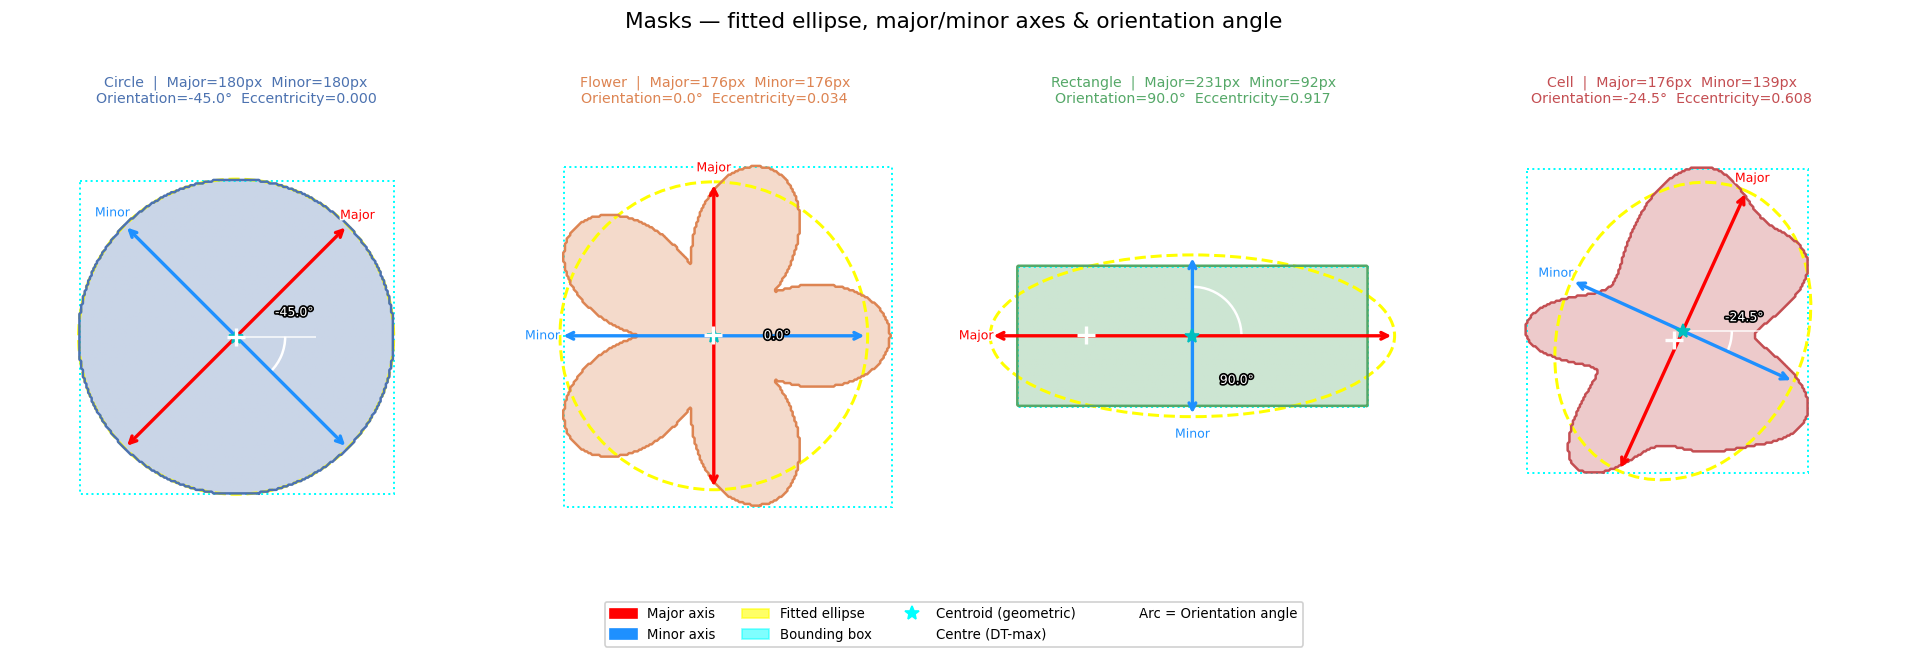

In [14]:
import matplotlib.patches as mpatches
from matplotlib.patches import Arc

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (name, mask) in zip(axes, masks.items()):
    p   = prop_objects[name]
    d   = results[name]
    col = COLORS[name]

    # ── shaded mask ───────────────────────────────────────────────────────
    rgba = np.zeros((*mask.shape, 4))
    rgba[mask == 1] = (*plt.matplotlib.colors.to_rgb(col), 0.30)
    ax.imshow(rgba)

    # ── contour ───────────────────────────────────────────────────────────
    for c in measure.find_contours(mask, 0.5):
        ax.plot(c[:, 1], c[:, 0], color=col, lw=1.5)

    # ── bounding box ──────────────────────────────────────────────────────
    bb = p.bbox
    ax.add_patch(plt.Rectangle(
        (bb[1], bb[0]), bb[3]-bb[1], bb[2]-bb[0],
        fill=False, edgecolor='cyan', lw=1.2, linestyle=':'))

    # ── fitted ellipse ────────────────────────────────────────────────────
    cy_c, cx_c = p.centroid          # geometric centroid (row, col)
    angle_deg  = np.degrees(p.orientation)   # skimage: angle from COL-axis to major
    ell = Ellipse(
        (cx_c, cy_c),
        width=p.minor_axis_length,
        height=p.major_axis_length,
        angle=-angle_deg,            # matplotlib uses CW degrees
        fill=False, edgecolor='yellow', lw=1.8, linestyle='--')
    ax.add_patch(ell)

    # ── axis arrows ───────────────────────────────────────────────────────
    # skimage orientation = angle between ROW-axis and major axis of ellipse,
    # measured CCW. In image coords (y down), major axis direction vector:
    orient_rad = p.orientation  + np.pi/2  # radians
    half_maj   = p.major_axis_length / 2
    half_min   = p.minor_axis_length / 2

    # Major axis direction (in row,col = y,x image coords)
    dy_maj = -np.sin(orient_rad)   # row component
    dx_maj =  np.cos(orient_rad)   # col component
    # Minor axis is perpendicular
    dy_min = -np.cos(orient_rad)
    dx_min = -np.sin(orient_rad)   # note: different sign convention

    # Draw major axis as red double-headed arrow
    ax.annotate('', xy=(cx_c + dx_maj*half_maj, cy_c + dy_maj*half_maj),
                xytext=(cx_c - dx_maj*half_maj, cy_c - dy_maj*half_maj),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2.0))
    ax.text(cx_c + dx_maj*(half_maj+8), cy_c + dy_maj*(half_maj+8),
            'Major', color='red', fontsize=7.5, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

    # Draw minor axis as blue double-headed arrow
    ax.annotate('', xy=(cx_c + dx_min*half_min, cy_c + dy_min*half_min),
                xytext=(cx_c - dx_min*half_min, cy_c - dy_min*half_min),
                arrowprops=dict(arrowstyle='<->', color='dodgerblue', lw=2.0))
    ax.text(cx_c + dx_min*(half_min+10), cy_c + dy_min*(half_min+10),
            'Minor', color='dodgerblue', fontsize=7.5, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

    # ── orientation angle arc ─────────────────────────────────────────────
    # Draw a horizontal reference line at centroid
    ref_len = 45
    ax.plot([cx_c, cx_c + ref_len], [cy_c, cy_c], color='white', lw=1.2, ls='-', alpha=0.7)

    # Arc from horizontal to major axis (matplotlib angle convention)
    arc_r = 28
    # angle of major axis in standard matplotlib degrees (CCW from +x)
    # skimage orientation: CCW from x-axis. Image y flips, so matplotlib angle = -orientation_deg
    mpl_angle = -angle_deg   # degrees
    # arc from 0 to mpl_angle (or handle wrapping)
    arc_start = min(0, mpl_angle)
    arc_end   = max(0, mpl_angle)
    arc = Arc((cx_c, cy_c), arc_r*2, arc_r*2,
              angle=0, theta1=arc_start, theta2=arc_end,
              color='white', lw=1.5)
    ax.add_patch(arc)
    # label the angle
    label_angle_rad = np.radians((arc_start + arc_end) / 2)
    lx = cx_c + (arc_r + 8) * np.cos(label_angle_rad)
    ly = cy_c - (arc_r + 8) * np.sin(label_angle_rad)
    ax.text(lx, ly, f'{angle_deg:.1f}°', color='white', fontsize=7.5,
            ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2, foreground='black')])

    # ── centroids ─────────────────────────────────────────────────────────
    dt_cy, dt_cx = d['Center_Y'], d['Center_X']
    ax.plot(cx_c, cy_c, 'c*', ms=9, label='Centroid', zorder=5)
    ax.plot(dt_cx, dt_cy, 'w+', ms=11, mew=2, label='DT-centre', zorder=5)

    ax.set_title(
        f'{name}  |  Major={p.major_axis_length:.0f}px  Minor={p.minor_axis_length:.0f}px\n'
        f'Orientation={angle_deg:.1f}°  Eccentricity={p.eccentricity:.3f}',
        color=col, fontsize=8.5)
    ax.set_xlim(0, SIZE); ax.set_ylim(SIZE, 0)
    ax.axis('off')

# shared legend
handles = [
    mpatches.Patch(color='red',       label='Major axis'),
    mpatches.Patch(color='dodgerblue',label='Minor axis'),
    mpatches.Patch(color='yellow',    alpha=0.6, label='Fitted ellipse'),
    mpatches.Patch(color='cyan',      alpha=0.5, label='Bounding box'),
    plt.Line2D([0],[0], marker='*', color='cyan',  ms=9, ls='', label='Centroid (geometric)'),
    plt.Line2D([0],[0], marker='+', color='white', ms=9, mew=2, ls='', label='Centre (DT-max)'),
    mpatches.Patch(color='white', alpha=0.6, label='Arc = Orientation angle'),
]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.06), framealpha=0.9)
plt.suptitle('Masks — fitted ellipse, major/minor axes & orientation angle', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

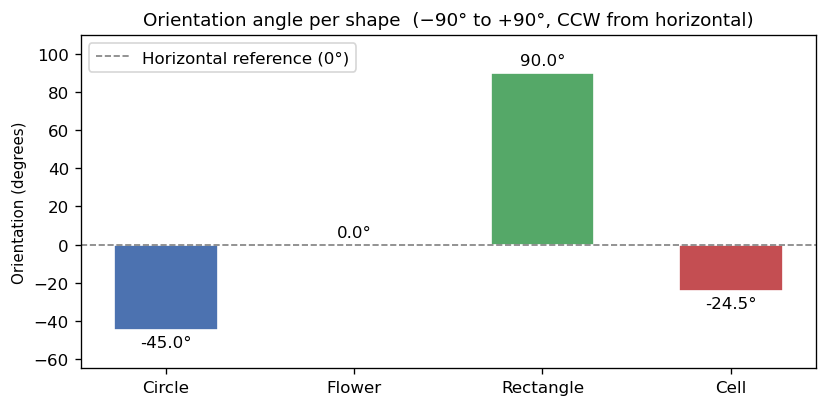

In [16]:
# Orientation summary bar chart
names = list(masks.keys())
bar_colors = [COLORS[n] for n in names]
orients = [results[n]['Orientation_deg'] for n in names]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(names, orients, color=bar_colors, width=0.55, edgecolor='white')
ax.bar_label(bars, fmt='%.1f°', padding=3, fontsize=10)
ax.axhline(0, color='gray', lw=1, ls='--', label='Horizontal reference (0°)')
ax.set_ylabel('Orientation (degrees)')
ax.set_ylim(min(orients)-20, max(orients)+20)
ax.set_title('Orientation angle per shape  (−90° to +90°, CCW from horizontal)')
ax.legend()
plt.tight_layout()
plt.show()

## 4 — Area, Perimeter & Equivalent Diameter

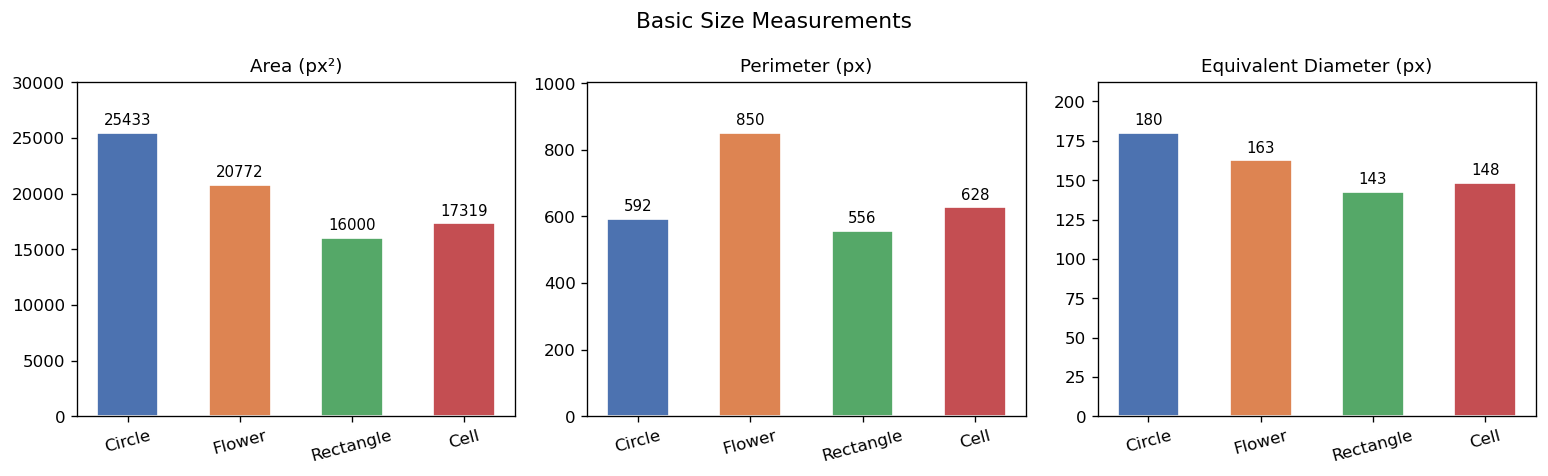

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ['Area', 'Perimeter', 'EquivalentDiameter']
titles  = ['Area (px²)', 'Perimeter (px)', 'Equivalent Diameter (px)']
for ax, m, ti in zip(axes, metrics, titles):
    vals = [results[n][m] for n in names]
    bars = ax.bar(names, vals, color=bar_colors, width=0.55, edgecolor='white')
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
    ax.set_title(ti); ax.set_ylim(0, max(vals)*1.18)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Basic Size Measurements', fontsize=13)
plt.tight_layout(); plt.show()

## 5 — Shape Indices: FormFactor, Compactness, Solidity, Eccentricity, Extent

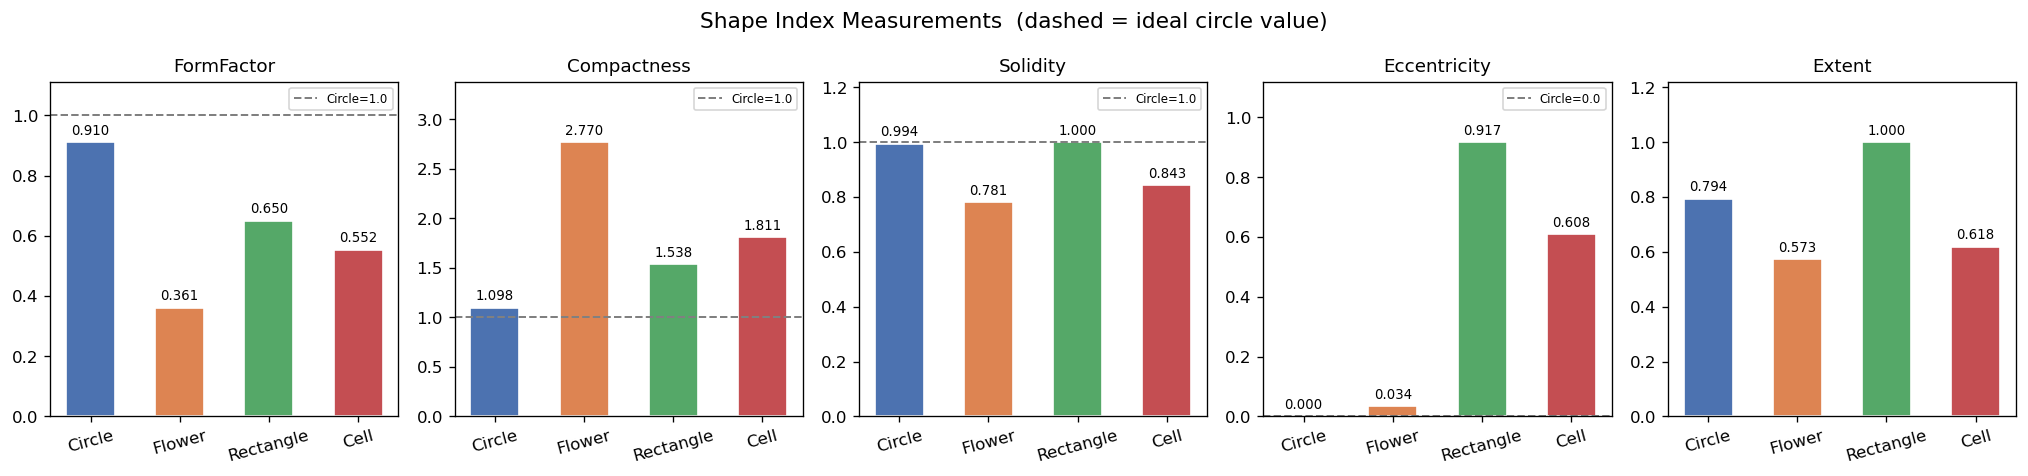

In [18]:
shape_metrics = ['FormFactor', 'Compactness', 'Solidity', 'Eccentricity', 'Extent']
ideal = {'FormFactor': 1.0, 'Compactness': 1.0, 'Solidity': 1.0,
         'Eccentricity': 0.0, 'Extent': None}

fig, axes = plt.subplots(1, 5, figsize=(17, 4))
for ax, metric in zip(axes, shape_metrics):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=bar_colors, width=0.55, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    ref = ideal[metric]
    if ref is not None:
        ax.axhline(ref, color='gray', lw=1.2, ls='--', label=f'Circle={ref}')
        ax.legend(fontsize=7)
    ax.set_title(metric); ax.set_ylim(0, max(vals)*1.22)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Shape Index Measurements  (dashed = ideal circle value)', fontsize=13)
plt.tight_layout(); plt.show()

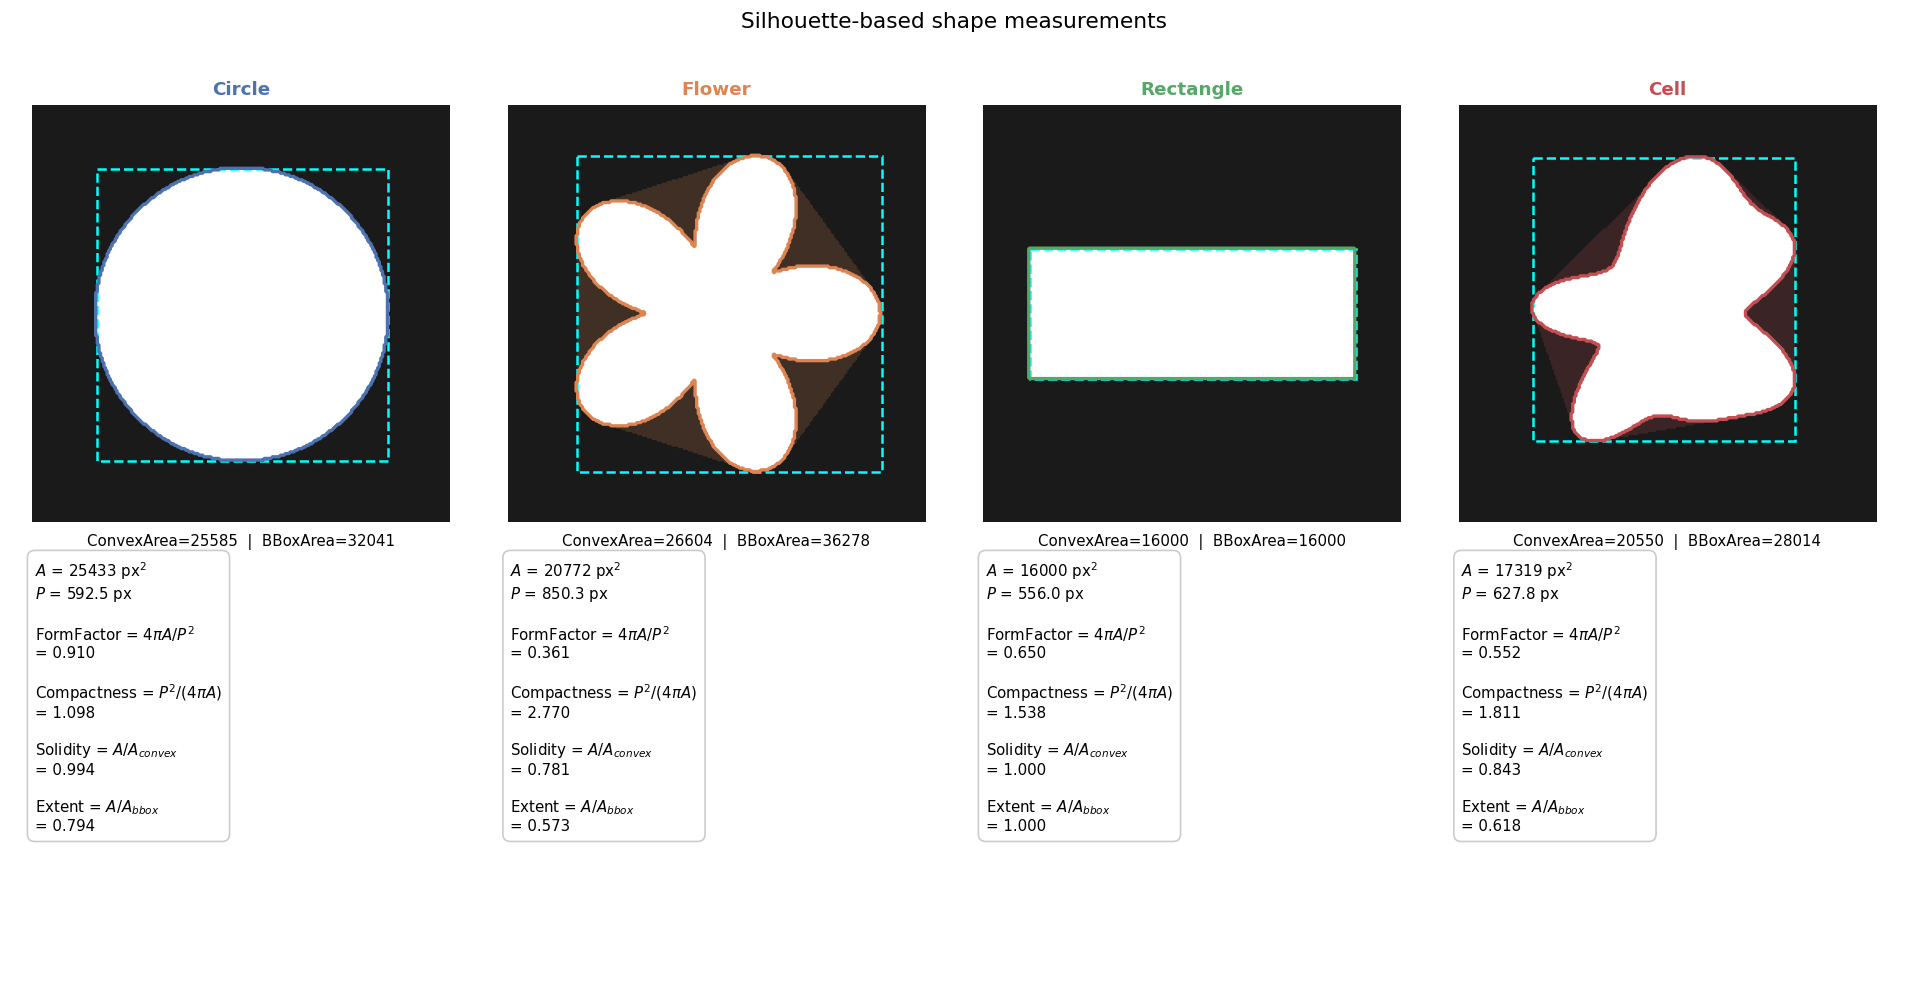

In [21]:
from skimage import measure

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (name, mask) in enumerate(masks.items()):
    p = prop_objects[name]
    color = COLORS[name]
    hull = convex_hull_image(mask)
    hull_gap = hull & ~mask.astype(bool)

    # ── silhouette view ──────────────────────────────────────────────────
    ax = axes[0, col]
    ax.imshow(mask, cmap='gray', vmin=0, vmax=1, alpha=0.9)

    # outline
    for c0 in measure.find_contours(mask, 0.5):
        ax.plot(c0[:, 1], c0[:, 0], color=color, lw=2)

    # convex hull
    h_rgba = np.zeros((*mask.shape, 4))
    h_rgba[hull_gap] = (*plt.matplotlib.colors.to_rgb(color), 0.20)
    ax.imshow(h_rgba)

    # bounding box
    bb = p.bbox
    ax.add_patch(plt.Rectangle(
        (bb[1], bb[0]), bb[3] - bb[1], bb[2] - bb[0],
        fill=False, edgecolor='cyan', lw=1.5, linestyle='--'
    ))

    ax.plot(p.centroid[1], p.centroid[0], 'w+', ms=10, mew=2)
    ax.set_title(name, color=color, fontweight='bold')
    ax.axis('off')

    # ── calculation panel ────────────────────────────────────────────────
    ax = axes[1, col]
    ax.axis('off')

    A = results[name]['Area']
    P = results[name]['Perimeter']
    CA = results[name]['ConvexArea']
    BBA = results[name]['BoundingBoxArea']
    FF = results[name]['FormFactor']
    CC = results[name]['Compactness']
    SO = results[name]['Solidity']
    EX = results[name]['Extent']

    txt = (
        f"$A$ = {A:.0f} px$^2$\n"
        f"$P$ = {P:.1f} px\n\n"
        f"FormFactor = $4\\pi A / P^2$\n"
        f"= {FF:.3f}\n\n"
        f"Compactness = $P^2 / (4\\pi A)$\n"
        f"= {CC:.3f}\n\n"
        f"Solidity = $A / A_{{convex}}$\n"
        f"= {SO:.3f}\n\n"
        f"Extent = $A / A_{{bbox}}$\n"
        f"= {EX:.3f}"
    )

    ax.text(
        0.05, 0.99, txt, va='top', ha='left', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='0.8')
    )

    ax.set_title(
        f"ConvexArea={CA:.0f}  |  BBoxArea={BBA:.0f}",
        fontsize=9
    )

plt.suptitle('Silhouette-based shape measurements', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

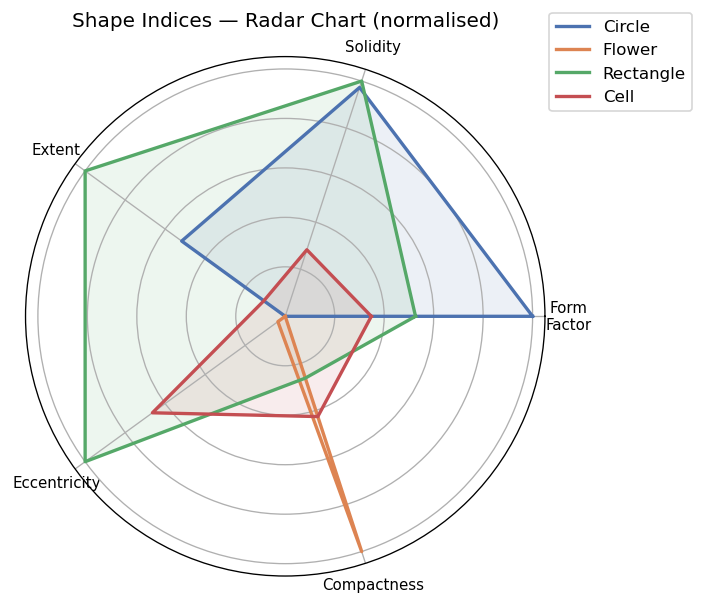

In [22]:
radar_metrics = ['FormFactor', 'Solidity', 'Extent', 'Eccentricity', 'Compactness']
radar_labels  = ['Form\nFactor', 'Solidity', 'Extent', 'Eccentricity', 'Compactness']
raw  = np.array([[results[n][m] for m in radar_metrics] for n in names], dtype=float)
norm = (raw - raw.min(0)) / np.where(raw.max(0)-raw.min(0)==0, 1, raw.max(0)-raw.min(0))
N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for i, name in enumerate(names):
    v = norm[i].tolist() + norm[i][:1].tolist()
    ax.plot(angles, v, color=COLORS[name], lw=2, label=name)
    ax.fill(angles, v, color=COLORS[name], alpha=0.1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_yticklabels([])
ax.set_title('Shape Indices — Radar Chart (normalised)', fontsize=12, pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()

## 6 — Axis Lengths

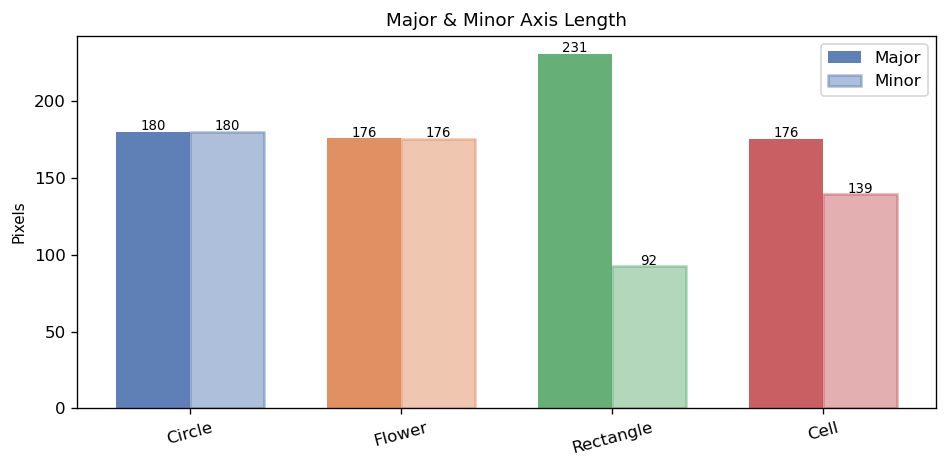

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(names)); w = 0.35
major = [results[n]['MajorAxisLength'] for n in names]
minor = [results[n]['MinorAxisLength'] for n in names]
b1 = ax.bar(x-w/2, major, w, label='Major', color=bar_colors, alpha=0.9)
b2 = ax.bar(x+w/2, minor, w, label='Minor', color=bar_colors, alpha=0.45,
            edgecolor=bar_colors, linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
ax.set_ylabel('Pixels'); ax.set_title('Major & Minor Axis Length')
for xi,(mv,nv) in enumerate(zip(major,minor)):
    ax.text(xi-w/2, mv+1, f'{mv:.0f}', ha='center', fontsize=8)
    ax.text(xi+w/2, nv+1, f'{nv:.0f}', ha='center', fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

## 7 — Bounding Box & Convex Hull

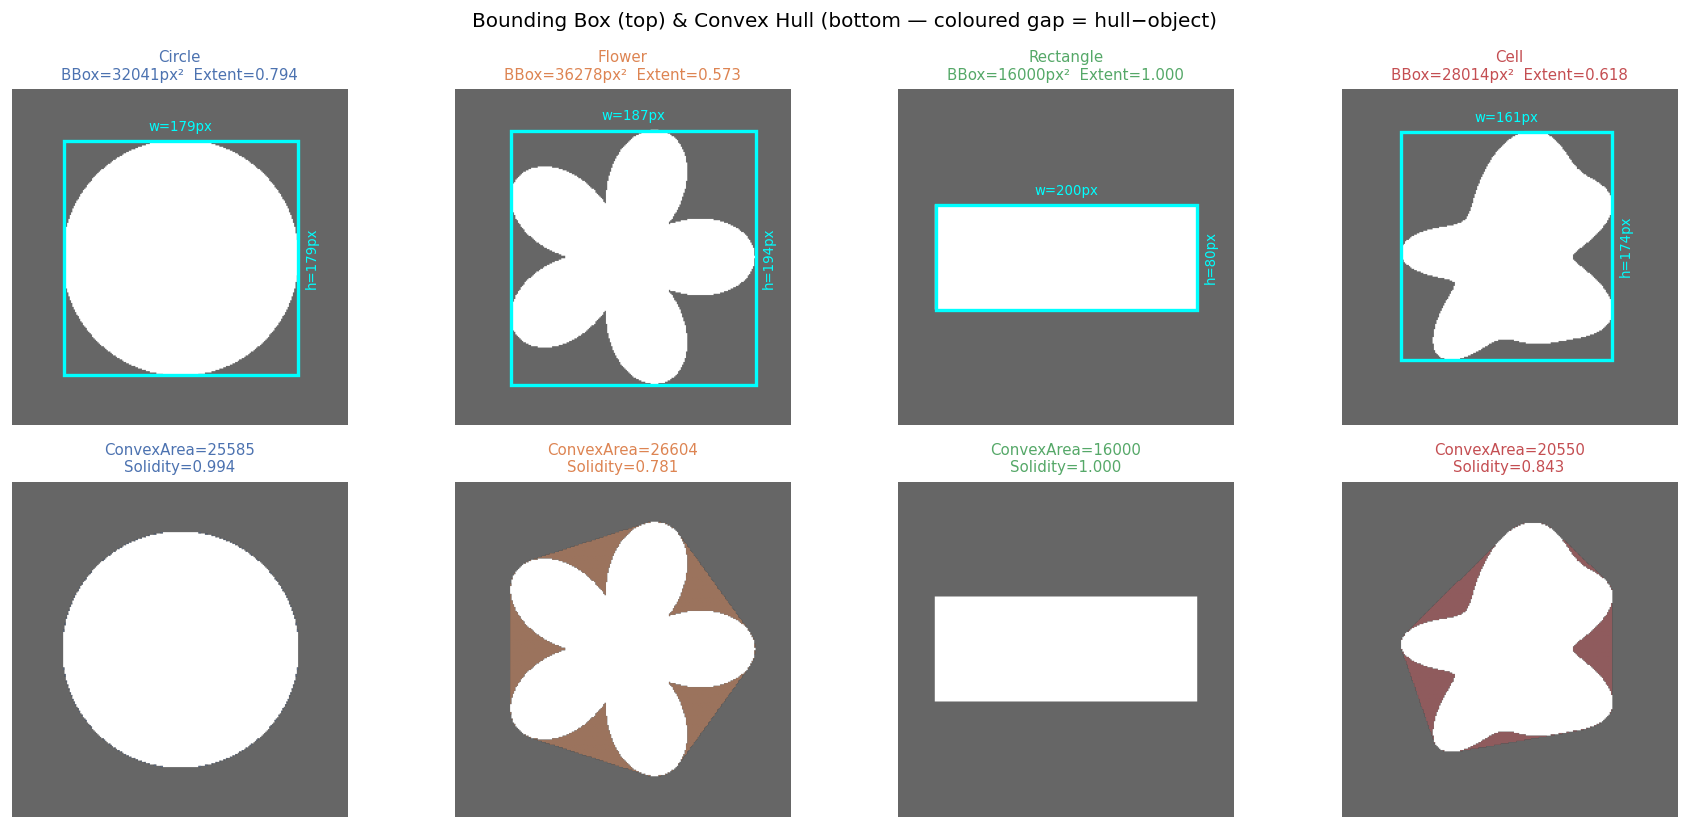

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for col, (name, mask) in enumerate(masks.items()):
    p = prop_objects[name]; color = COLORS[name]
    hull = convex_hull_image(mask)

    ax = axes[0][col]
    ax.imshow(mask, cmap='gray', vmin=0, vmax=1, alpha=0.6)
    bb = p.bbox; w_px=bb[3]-bb[1]; h_px=bb[2]-bb[0]
    ax.add_patch(plt.Rectangle((bb[1],bb[0]),w_px,h_px,fill=False,edgecolor='cyan',lw=2))
    ax.text(bb[1]+w_px/2, bb[0]-8, f'w={w_px}px', ha='center', color='cyan', fontsize=8)
    ax.text(bb[3]+5, bb[0]+h_px/2, f'h={h_px}px', va='center', color='cyan', fontsize=8, rotation=90)
    ax.set_title(f'{name}\nBBox={results[name]["BoundingBoxArea"]:.0f}px²  Extent={results[name]["Extent"]:.3f}',
                 color=color, fontsize=9); ax.axis('off')

    ax = axes[1][col]
    ax.imshow(mask, cmap='gray', vmin=0, vmax=1, alpha=0.6)
    h_rgba = np.zeros((*mask.shape,4))
    h_rgba[hull & ~mask.astype(bool)] = (*plt.matplotlib.colors.to_rgb(color), 0.45)
    ax.imshow(h_rgba)
    ax.set_title(f'ConvexArea={results[name]["ConvexArea"]:.0f}\nSolidity={results[name]["Solidity"]:.3f}',
                 color=color, fontsize=9); ax.axis('off')

axes[0][0].set_ylabel('Bounding Box', fontsize=10)
axes[1][0].set_ylabel('Convex Hull', fontsize=10)
plt.suptitle('Bounding Box (top) & Convex Hull (bottom — coloured gap = hull−object)', fontsize=12)
plt.tight_layout(); plt.show()

## 8 — Radial Distance Profiles (Max, Mean, Median Radius)

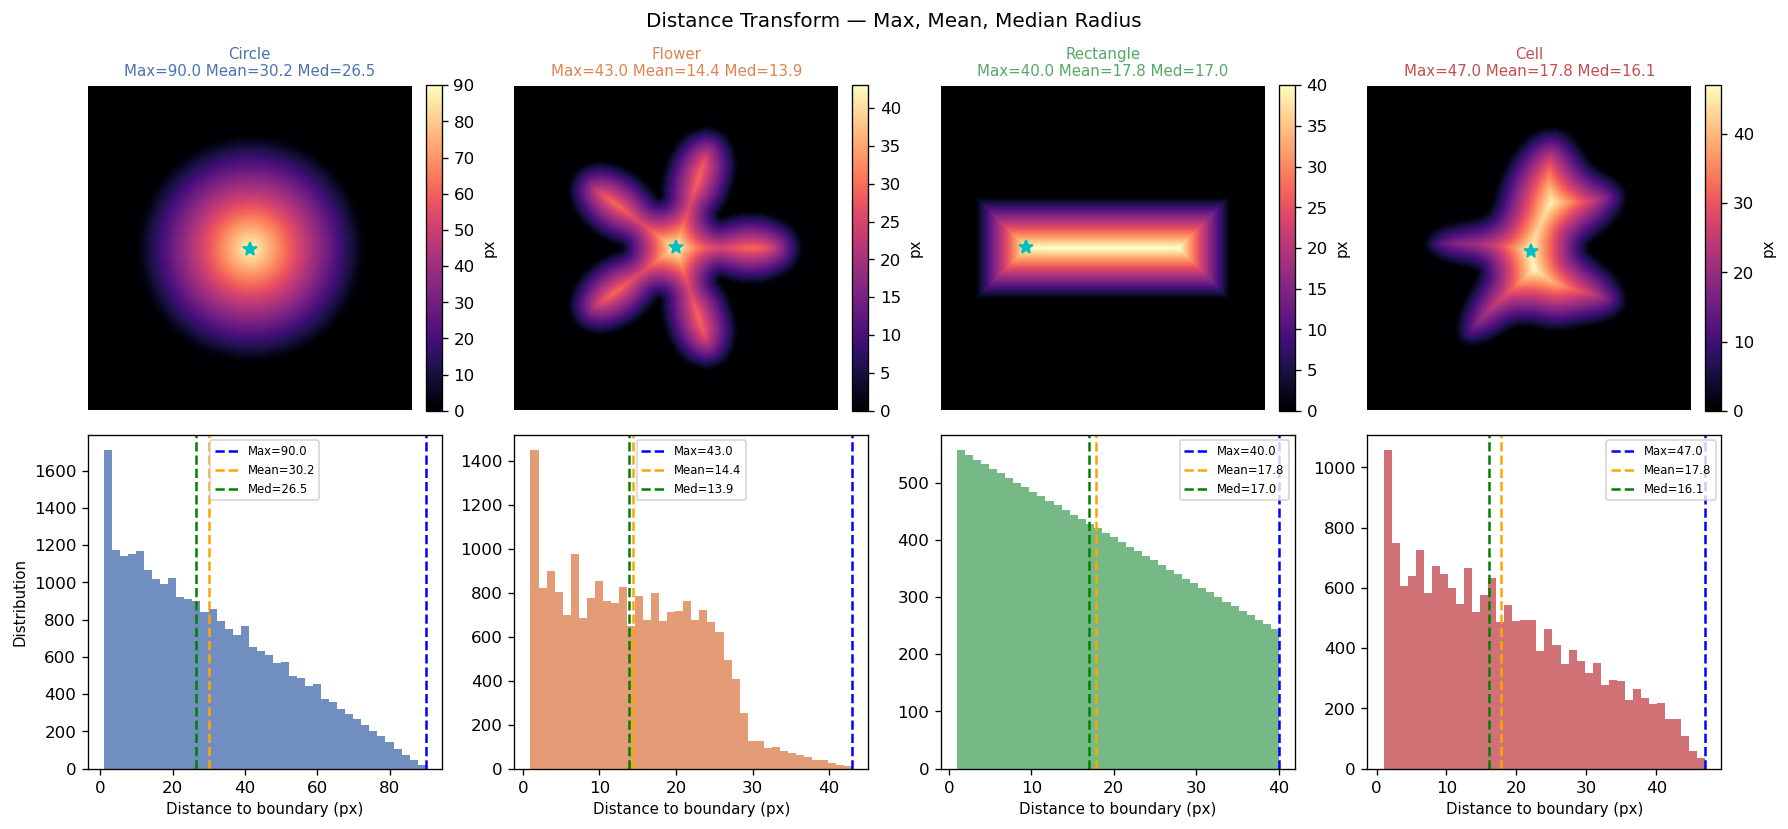

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for col, (name, mask) in enumerate(masks.items()):
    color = COLORS[name]
    dist = distance_transform_edt(mask)
    d_vals = dist[mask.astype(bool)]
    max_r = d_vals.max(); mean_r = d_vals.mean(); med_r = np.median(d_vals)

    ax = axes[0][col]
    im = ax.imshow(dist, cmap='magma')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='px')
    mp = np.unravel_index(dist.argmax(), dist.shape)
    ax.plot(mp[1], mp[0], 'c*', ms=9)
    ax.set_title(f'{name}\nMax={max_r:.1f} Mean={mean_r:.1f} Med={med_r:.1f}',
                 color=color, fontsize=9); ax.axis('off')

    ax = axes[1][col]
    ax.hist(d_vals, bins=40, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(max_r,  color='blue',   ls='--', lw=1.5, label=f'Max={max_r:.1f}')
    ax.axvline(mean_r, color='orange', ls='--', lw=1.5, label=f'Mean={mean_r:.1f}')
    ax.axvline(med_r,  color='green',  ls='--', lw=1.5, label=f'Med={med_r:.1f}')
    ax.legend(fontsize=7); ax.set_xlabel('Distance to boundary (px)')

axes[0][0].set_ylabel('Distance Map'); axes[1][0].set_ylabel('Distribution')
plt.suptitle('Distance Transform — Max, Mean, Median Radius', fontsize=12)
plt.tight_layout(); plt.show()

## 9 — Feret Diameter (Caliper)

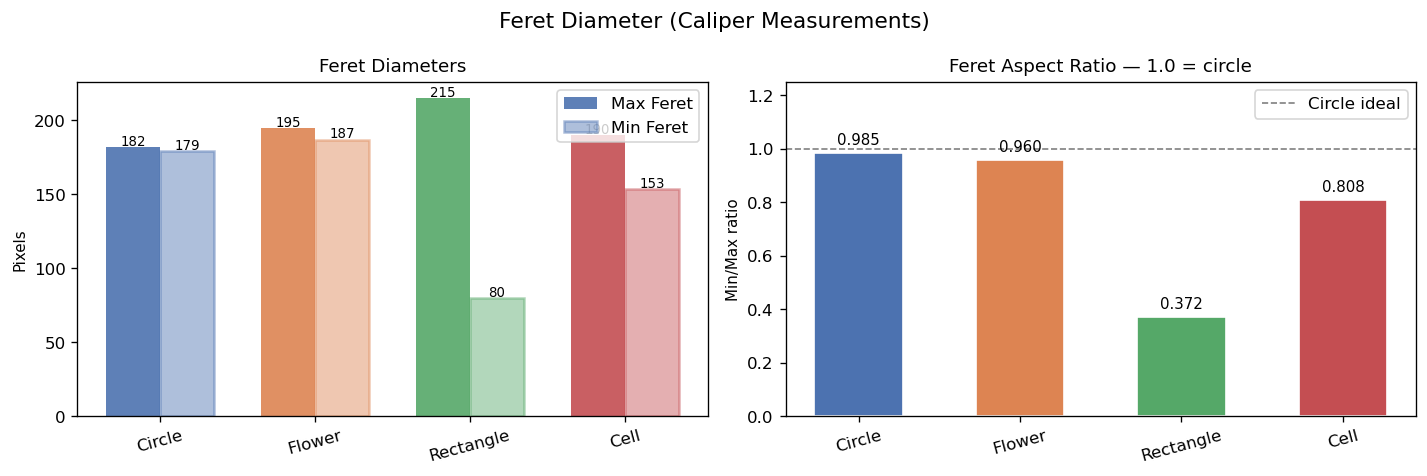

In [26]:
def min_feret(mask):
    pts = np.vstack(measure.find_contours(mask, 0.5))
    min_w = np.inf
    for angle in np.linspace(0, np.pi, 180):
        rot = np.array([[np.cos(angle),-np.sin(angle)],[np.sin(angle),np.cos(angle)]])
        rotated = pts @ rot.T
        min_w = min(min_w, rotated[:,0].max()-rotated[:,0].min())
    return min_w

feret_data = {n: {'MaxFeret': prop_objects[n].feret_diameter_max,
                  'MinFeret': min_feret(masks[n])} for n in names}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(names)); w = 0.35
max_f = [feret_data[n]['MaxFeret'] for n in names]
min_f = [feret_data[n]['MinFeret'] for n in names]

axes[0].bar(x-w/2, max_f, w, label='Max Feret', color=bar_colors, alpha=0.9)
axes[0].bar(x+w/2, min_f, w, label='Min Feret', color=bar_colors, alpha=0.45,
            edgecolor=bar_colors, linewidth=1.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=15)
for xi,(mv,nv) in enumerate(zip(max_f,min_f)):
    axes[0].text(xi-w/2, mv+1, f'{mv:.0f}', ha='center', fontsize=8)
    axes[0].text(xi+w/2, nv+1, f'{nv:.0f}', ha='center', fontsize=8)
axes[0].set_ylabel('Pixels'); axes[0].set_title('Feret Diameters'); axes[0].legend()

ratios = [feret_data[n]['MinFeret']/feret_data[n]['MaxFeret'] for n in names]
bars = axes[1].bar(names, ratios, color=bar_colors, width=0.55, edgecolor='white')
axes[1].bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
axes[1].axhline(1.0, color='gray', ls='--', lw=1, label='Circle ideal')
axes[1].set_ylabel('Min/Max ratio'); axes[1].set_ylim(0, 1.25)
axes[1].set_title('Feret Aspect Ratio — 1.0 = circle'); axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)
plt.suptitle('Feret Diameter (Caliper Measurements)', fontsize=13)
plt.tight_layout(); plt.show()

## 10 — Euler Number (Topology)

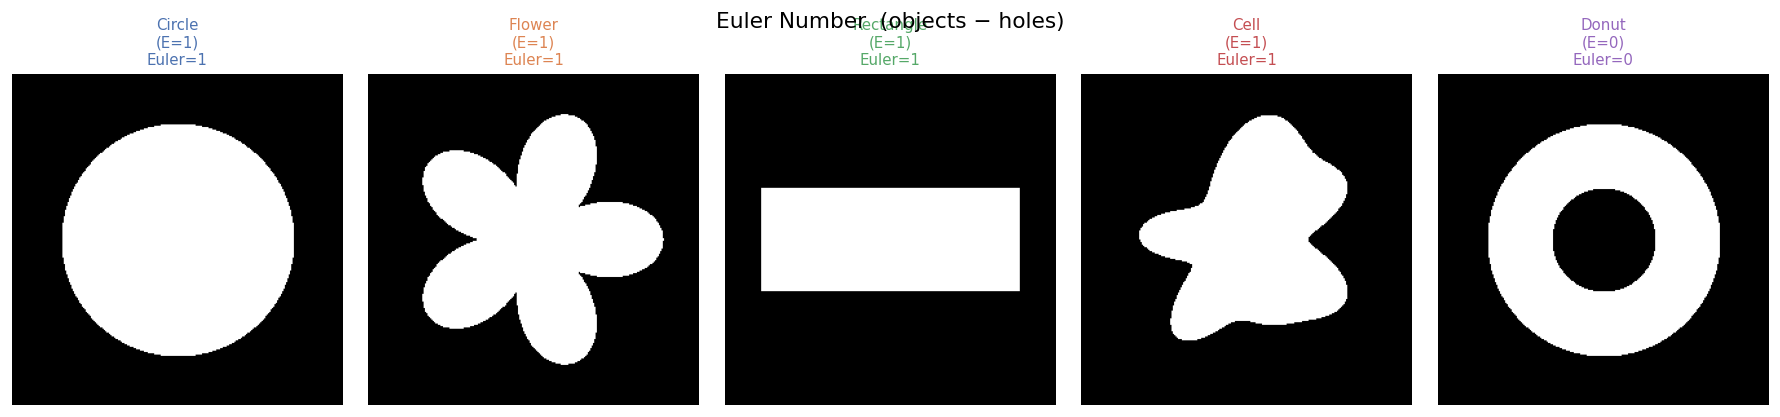

In [27]:
donut_mask = circle_mask.copy()
rr, cc = draw.disk((CX, CY), radius=40, shape=donut_mask.shape)
donut_mask[rr, cc] = 0

euler_demo = {'Circle\n(E=1)': circle_mask, 'Flower\n(E=1)': flower_mask,
              'Rectangle\n(E=1)': rect_mask, 'Cell\n(E=1)': cell_mask,
              'Donut\n(E=0)': donut_mask}
euler_colors = list(COLORS.values()) + ['#9467bd']

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, (label, m), col in zip(axes, euler_demo.items(), euler_colors):
    lbl = measure.label(m)
    e = regionprops(lbl)[0].euler_number if lbl.max() > 0 else '—'
    ax.imshow(m, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'{label}\nEuler={e}', color=col, fontsize=9); ax.axis('off')
plt.suptitle('Euler Number  (objects − holes)', fontsize=13)
plt.tight_layout(); plt.show()

## 11 — Central Moments

### What are Central Moments?

A **moment** is a weighted average over the pixels of an object.  
For a binary mask $f(x,y) \in \{0,1\}$, the **spatial moment** of order $(p,q)$ is:

$$m_{pq} = \sum_x \sum_y x^p \, y^q \, f(x,y)$$

**Central moments** shift the origin to the **centroid** $(\bar{x}, \bar{y})$ first, making them **translation-invariant**:

$$\mu_{pq} = \sum_x \sum_y (x - \bar{x})^p \,(y - \bar{y})^q \, f(x,y)$$

| Order | What it encodes |
|---|---|
| $\mu_{00}$ | Area (= number of pixels) |
| $\mu_{10}, \mu_{01}$ | Always 0 by definition (centred at centroid) |
| $\mu_{20}, \mu_{02}$ | **Variance** in x and y — related to axis lengths |
| $\mu_{11}$ | **Covariance** between x and y — encodes orientation |
| $\mu_{30}, \mu_{03}$ | **Skewness** — asymmetry of shape along each axis |
| Higher | Increasingly fine structural detail |

> **Key insight:** $\mu_{20}$, $\mu_{02}$, $\mu_{11}$ together define the **inertia ellipse** — they are exactly what skimage uses to compute `MajorAxisLength`, `MinorAxisLength`, and `Orientation`.

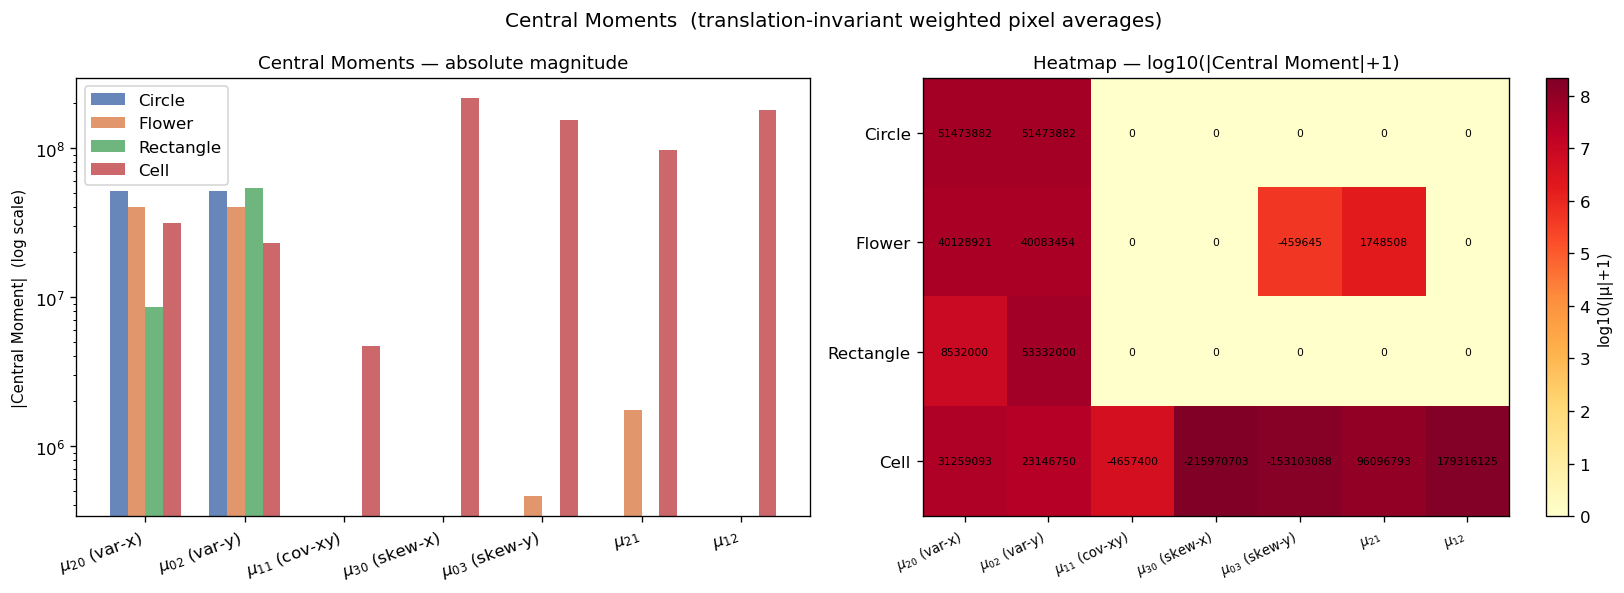

In [28]:
# visualise μ20, μ02, μ11 for each shape
cm_keys = ['CentralMoment_20', 'CentralMoment_02', 'CentralMoment_11',
           'CentralMoment_30', 'CentralMoment_03', 'CentralMoment_21', 'CentralMoment_12']
labels  = [r'$\mu_{20}$ (var-x)', r'$\mu_{02}$ (var-y)', r'$\mu_{11}$ (cov-xy)',
           r'$\mu_{30}$ (skew-x)', r'$\mu_{03}$ (skew-y)', r'$\mu_{21}$', r'$\mu_{12}$']

cm_data = np.array([[results[n][k] for k in cm_keys] for n in names])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── left: absolute values (log scale) ────────────────────────────────────
ax = axes[0]
x = np.arange(len(cm_keys)); w = 0.18
for i, name in enumerate(names):
    vals = np.abs(cm_data[i])
    ax.bar(x + i*w, vals, w, label=name, color=COLORS[name], alpha=0.85)
ax.set_yscale('log')
ax.set_xticks(x + 1.5*w); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('|Central Moment|  (log scale)')
ax.set_title('Central Moments — absolute magnitude')
ax.legend()

# ── right: normalised heatmap ─────────────────────────────────────────────
ax = axes[1]
norm_cm = np.log10(np.abs(cm_data) + 1)
im = ax.imshow(norm_cm, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(cm_keys))); ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
plt.colorbar(im, ax=ax, label='log10(|μ|+1)')
for r in range(len(names)):
    for c in range(len(cm_keys)):
        ax.text(c, r, f'{cm_data[r,c]:.0f}', ha='center', va='center', fontsize=6.5)
ax.set_title('Heatmap — log10(|Central Moment|+1)')

plt.suptitle('Central Moments  (translation-invariant weighted pixel averages)', fontsize=12)
plt.tight_layout(); plt.show()

## 12 — Hu Moments

### What are Hu Moments?

Hu moments (Ming-Kuei Hu, 1962) are **seven scalar values** derived from the normalised central moments.  
They are invariant to **translation, scale, and rotation** (and some to reflection).

**Normalised central moments** first make central moments scale-invariant:

$$\eta_{pq} = \frac{\mu_{pq}}{\mu_{00}^{1 + (p+q)/2}}$$

Then the seven Hu moments are specific polynomial combinations of $\eta_{pq}$:

| Moment | Formula sketch | Physical meaning |
|---|---|---|
| $h_1$ | $\eta_{20} + \eta_{02}$ | Total "spread" — like moment of inertia |
| $h_2$ | $(\eta_{20}-\eta_{02})^2 + 4\eta_{11}^2$ | Elongation / eccentricity |
| $h_3$ | $(\eta_{30}-3\eta_{12})^2 + (3\eta_{21}-\eta_{03})^2$ | Triangular asymmetry |
| $h_4$ | $(\eta_{30}+\eta_{12})^2 + (\eta_{21}+\eta_{03})^2$ | Higher-order spread |
| $h_5$ | Cross-terms of $h_3$ factors | Skewed asymmetry |
| $h_6$ | $(\eta_{20}-\eta_{02})\cdot[\ldots] + 4\eta_{11}\cdot[\ldots]$ | Orientation × elongation |
| $h_7$ | Anti-symmetric combination | Sign flips for mirror images |

> **Key properties:**
> - $h_1$ is large for spread objects, small for compact ones.  
> - $h_1 = h_2 = 0$ for a perfect circle (fully symmetric).  
> - Values span many orders of magnitude → always compare in **log scale**.  
> - Commonly used as a **shape fingerprint** for object classification.

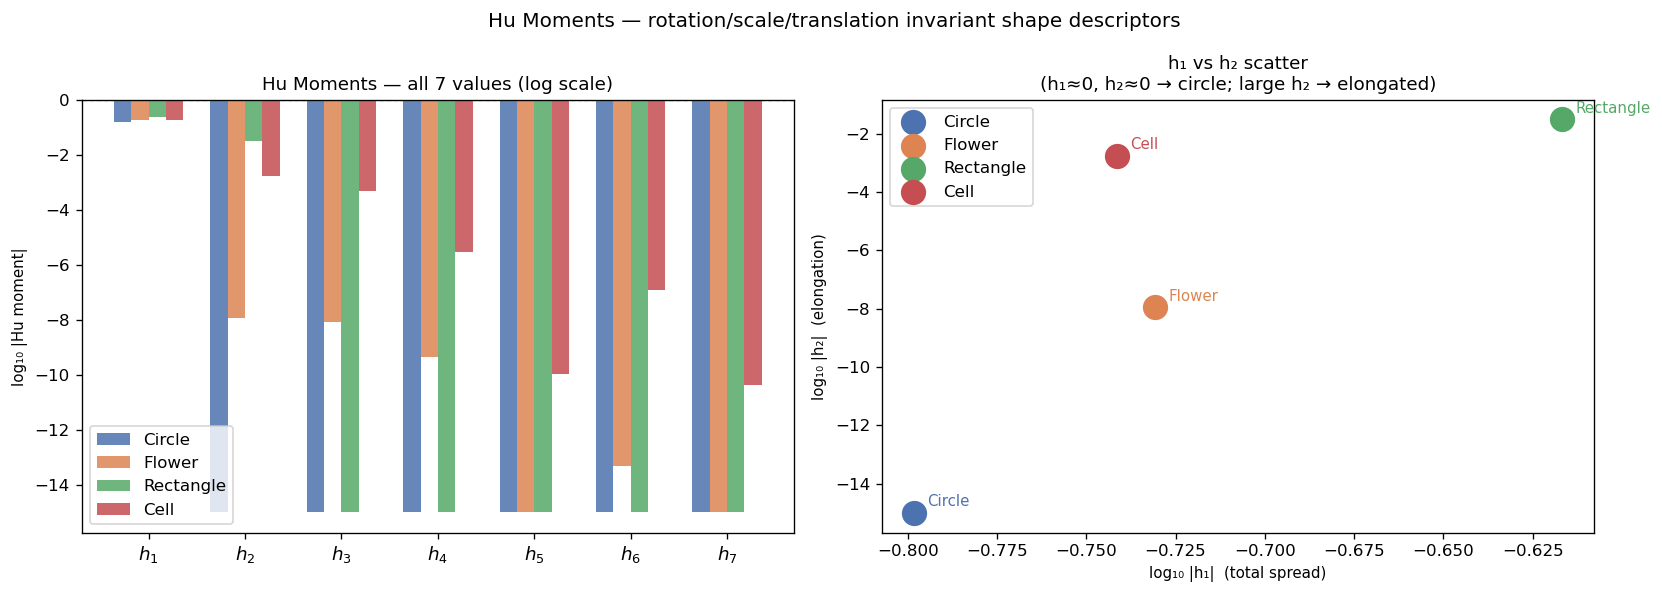

In [29]:
hu_data = np.array([[results[n][f'HuMoment_{i+1}'] for i in range(7)] for n in names])
hu_log  = np.log10(np.abs(hu_data) + 1e-15)
hu_labels = [f'$h_{i+1}$' for i in range(7)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── bar chart ─────────────────────────────────────────────────────────────
ax = axes[0]
x = np.arange(7); w = 0.18
for i, name in enumerate(names):
    ax.bar(x + i*w, hu_log[i], w, label=name, color=COLORS[name], alpha=0.85)
ax.set_xticks(x + 1.5*w); ax.set_xticklabels(hu_labels, fontsize=11)
ax.set_ylabel('log₁₀ |Hu moment|')
ax.set_title('Hu Moments — all 7 values (log scale)')
ax.legend()
ax.axhline(0, color='gray', ls='--', lw=0.8)

# ── scatter: h1 vs h2 (the two most informative) ─────────────────────────
ax = axes[1]
for i, name in enumerate(names):
    h1 = np.log10(abs(hu_data[i,0]) + 1e-15)
    h2 = np.log10(abs(hu_data[i,1]) + 1e-15)
    ax.scatter(h1, h2, color=COLORS[name], s=200, zorder=5, label=name)
    ax.annotate(name, (h1, h2), textcoords='offset points',
                xytext=(8, 4), fontsize=9, color=COLORS[name])
ax.set_xlabel('log₁₀ |h₁|  (total spread)')
ax.set_ylabel('log₁₀ |h₂|  (elongation)')
ax.set_title('h₁ vs h₂ scatter\n(h₁≈0, h₂≈0 → circle; large h₂ → elongated)')
ax.legend()

plt.suptitle('Hu Moments — rotation/scale/translation invariant shape descriptors', fontsize=12)
plt.tight_layout(); plt.show()

## 13 — Inertia Tensor & Eigenvalues

### What is the Inertia Tensor?

The **inertia tensor** $\mathbf{I}$ describes how the mass (pixels) of an object is distributed around its centroid — analogous to the **moment of inertia** in physics.

For a 2D binary mask centred at its centroid:

$$\mathbf{I} = \begin{pmatrix} I_{rr} & I_{rc} \\ I_{cr} & I_{cc} \end{pmatrix} = \begin{pmatrix} \mu_{02} & -\mu_{11} \\ -\mu_{11} & \mu_{20} \end{pmatrix}$$

where $\mu_{pq}$ are the central moments.

| Entry | Meaning |
|---|---|
| $I_{rr} = \mu_{02}$ | Resistance to rotation around the **row** (x) axis — spread in y |
| $I_{cc} = \mu_{20}$ | Resistance to rotation around the **column** (y) axis — spread in x |
| $I_{rc} = -\mu_{11}$ | Cross-term — non-zero if axes are tilted |

### Eigenvalues

The **eigenvalues** $\lambda_1 \geq \lambda_2$ of $\mathbf{I}$ are the inertia along the **principal axes** (the axes that diagonalise the tensor):

- **$\lambda_1$** = inertia along the axis of **minimum** spread → corresponds to the **major axis** direction
- **$\lambda_2$** = inertia along the axis of **maximum** spread → corresponds to the **minor axis** direction
- **Ratio $\lambda_2 / \lambda_1$** → 1 for circles, large for elongated shapes

> **Connection to `MajorAxisLength`:**  
> skimage computes axis lengths as $4\sqrt{\lambda/\text{Area}}$, so the eigenvalues *directly determine* the axis lengths.

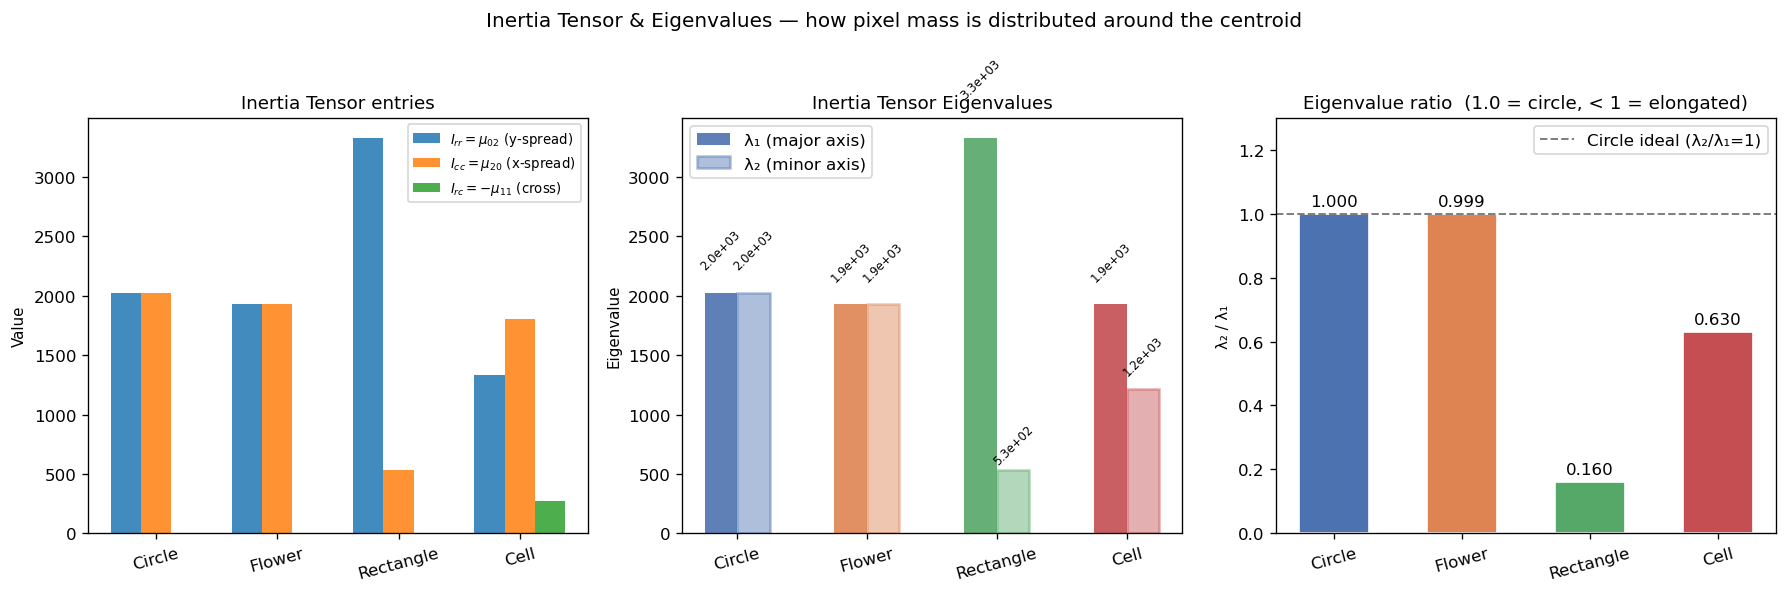

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names_list = list(names)

# ── tensor entries ────────────────────────────────────────────────────────
ax = axes[0]
entries = ['InertiaTensor_00', 'InertiaTensor_11', 'InertiaTensor_01']
entry_labels = [r'$I_{rr}=\mu_{02}$ (y-spread)', r'$I_{cc}=\mu_{20}$ (x-spread)', r'$I_{rc}=-\mu_{11}$ (cross)']
x = np.arange(len(names_list)); w = 0.25
for i, (key, lbl) in enumerate(zip(entries, entry_labels)):
    vals = [results[n][key] for n in names_list]
    ax.bar(x + i*w, vals, w, label=lbl, alpha=0.85)
ax.set_xticks(x + w); ax.set_xticklabels(names_list, rotation=15)
ax.set_ylabel('Value'); ax.set_title('Inertia Tensor entries')
ax.legend(fontsize=8)

# ── eigenvalues ───────────────────────────────────────────────────────────
ax = axes[1]
eig1 = [results[n]['InertiaTensorEigenvalue_1'] for n in names_list]
eig2 = [results[n]['InertiaTensorEigenvalue_2'] for n in names_list]
ax.bar(x-w/2, eig1, w, label='λ₁ (major axis)', color=bar_colors, alpha=0.9)
ax.bar(x+w/2, eig2, w, label='λ₂ (minor axis)', color=bar_colors, alpha=0.45,
       edgecolor=bar_colors, linewidth=1.5)
for xi,(v1,v2) in enumerate(zip(eig1,eig2)):
    ax.text(xi-w/2, v1*1.1, f'{v1:.1e}', ha='center', fontsize=7, rotation=45)
    ax.text(xi+w/2, v2*1.1, f'{v2:.1e}', ha='center', fontsize=7, rotation=45)
ax.set_xticks(x); ax.set_xticklabels(names_list, rotation=15)
ax.set_ylabel('Eigenvalue'); ax.set_title('Inertia Tensor Eigenvalues')
ax.legend()

# ── ratio λ2/λ1 ──────────────────────────────────────────────────────────
ax = axes[2]
ratios = [e2/e1 if e1 > 0 else 0 for e1,e2 in zip(eig1,eig2)]
bars = ax.bar(names_list, ratios, color=bar_colors, width=0.55, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.axhline(1.0, color='gray', ls='--', lw=1.2, label='Circle ideal (λ₂/λ₁=1)')
ax.set_ylabel('λ₂ / λ₁')
ax.set_title('Eigenvalue ratio  (1.0 = circle, < 1 = elongated)')
ax.set_ylim(0, 1.3); ax.legend(); ax.tick_params(axis='x', rotation=15)

plt.suptitle('Inertia Tensor & Eigenvalues — how pixel mass is distributed around the centroid',
             fontsize=12)
plt.tight_layout(); plt.show()

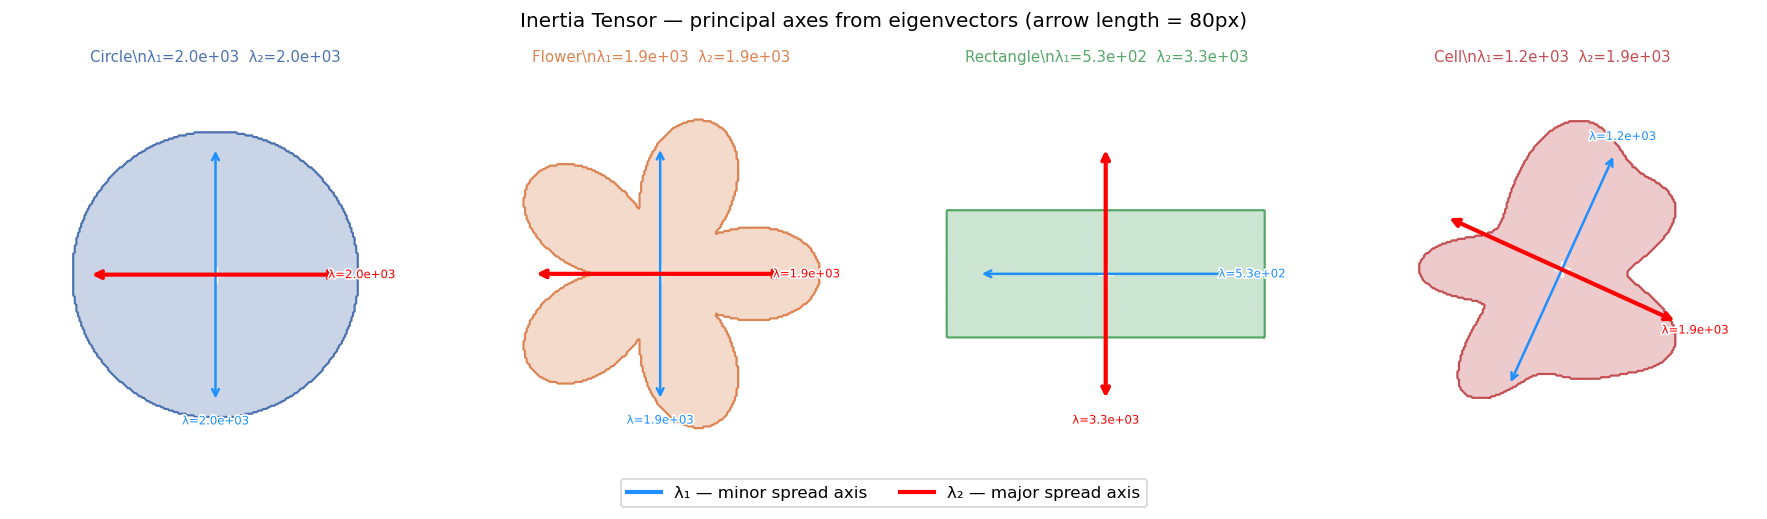

In [35]:
# Show the principal axes from eigenvectors on each mask
from numpy.linalg import eigh

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (name, mask) in zip(axes, masks.items()):
    p = prop_objects[name]; color = COLORS[name]
    rgba = np.zeros((*mask.shape, 4))
    rgba[mask==1] = (*plt.matplotlib.colors.to_rgb(color), 0.30)
    ax.imshow(rgba)
    for c in measure.find_contours(mask, 0.5):
        ax.plot(c[:,1], c[:,0], color=color, lw=1.3)

    cy_c, cx_c = p.centroid
    It = p.inertia_tensor
    eigvals, eigvecs = eigh(It)   # eigvecs[:,i] = eigenvector for eigvals[i]

    scale = 80
    for idx, (ev, ec) in enumerate(zip(eigvals, eigvecs.T)):
        # eigvecs are in (row, col) = (y, x) space
        dy, dx = ec[0], ec[1]
        lw = 2.5 if idx == 1 else 1.5   # larger eigval = minor axis (more spread)
        lc = 'red' if idx == 1 else 'dodgerblue'
        lbl = f'λ={ev:.1e}'
        ax.annotate('', xy=(cx_c+dx*scale, cy_c+dy*scale),
                    xytext=(cx_c-dx*scale, cy_c-dy*scale),
                    arrowprops=dict(arrowstyle='<->', color=lc, lw=lw))
        ax.text(cx_c+dx*(scale+12), cy_c+dy*(scale+12), lbl,
                color=lc, fontsize=7, ha='center', va='center',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])

    ax.plot(cx_c, cy_c, 'w+', ms=10, mew=2)
    ax.set_title(f'{name}\\nλ₁={eigvals[0]:.1e}  λ₂={eigvals[1]:.1e}',
                 color=color, fontsize=9)
    ax.set_xlim(0,SIZE); ax.set_ylim(SIZE,0); ax.axis('off')

handles = [plt.Line2D([0],[0],color='dodgerblue',lw=2.5,label='λ₁ — minor spread axis'),
           plt.Line2D([0],[0],color='red',lw=2.5,label='λ₂ — major spread axis')]
fig.legend(handles=handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.04))
plt.suptitle('Inertia Tensor — principal axes from eigenvectors (arrow length = 80px)',
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

## 14 — Full Summary Heatmap

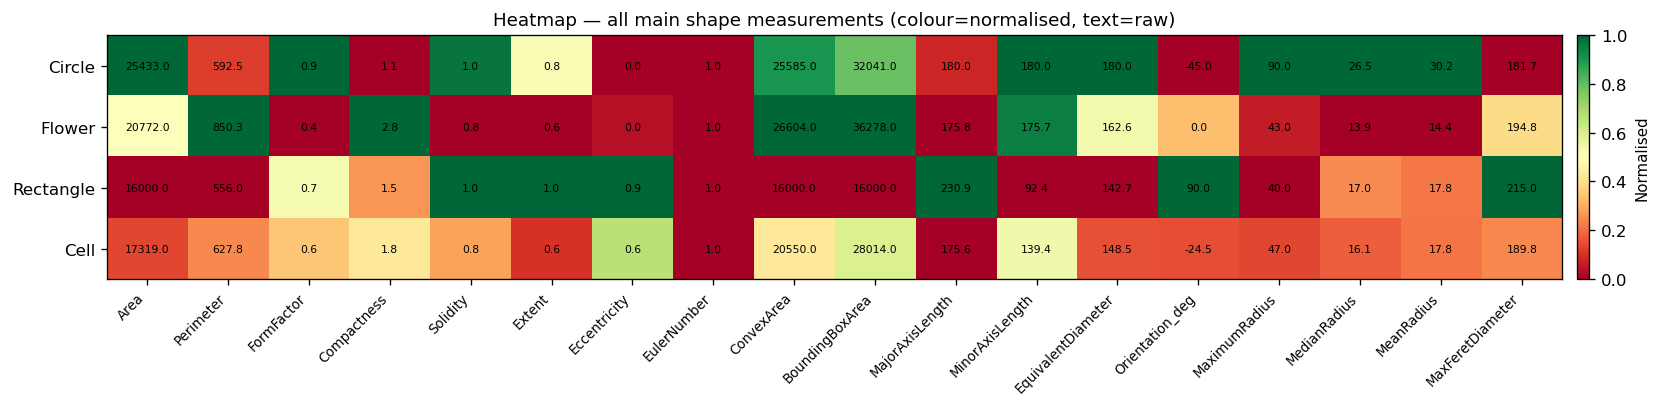

In [36]:
summary = pd.DataFrame(results).T.round(3)
drop_cols = ['Center_X','Center_Y','Centroid_X','Centroid_Y',
             'BBox_MinRow','BBox_MinCol','BBox_MaxRow','BBox_MaxCol','MinFeretDiameter']
drop_cols += [c for c in summary.columns if any(c.startswith(x) for x in
              ['Moment_','CentralMoment_','NormalizedMoment_','HuMoment_',
               'InertiaTensor_','InertiaTensorEigenvalue_'])]
s = summary.drop(columns=[c for c in drop_cols if c in summary.columns]).astype(float)
norm_s = (s - s.min()) / (s.max() - s.min() + 1e-12)

fig, ax = plt.subplots(figsize=(14, 3.5))
im = ax.imshow(norm_s.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(s.columns))); ax.set_xticklabels(s.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label='Normalised')
for r in range(len(names)):
    for c in range(len(s.columns)):
        ax.text(c, r, f'{s.values[r,c]:.1f}', ha='center', va='center', fontsize=6.5)
ax.set_title('Heatmap — all main shape measurements (colour=normalised, text=raw)', fontsize=11)
plt.tight_layout(); plt.show()